# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Hussainhhgh/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
from google.colab import userdata
import duckdb
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

hf_token = userdata.get('HF_TOKEN')
con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{hf_token}')")
month_path = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet"

feature_query = f"""
    SELECT content_hash_id, client_hash_id,
        SUM(gsc_impressions) as impressions_15d,
        SUM(gsc_clicks) as clicks_15d,
        AVG(gsc_avg_position) as avg_position_15d
    FROM read_parquet('{month_path}')
    WHERE report_date <= DATE '2026-03-15' AND gsc_data_available = TRUE
    GROUP BY content_hash_id, client_hash_id
    HAVING SUM(gsc_impressions) > 0
"""
features_df = con.sql(feature_query).df()

label_query = f"""
    SELECT content_hash_id, SUM(gsc_clicks) as clicks_1631
    FROM read_parquet('{month_path}')
    WHERE report_date >= DATE '2026-03-16' AND gsc_data_available = TRUE
    GROUP BY content_hash_id
"""
labels_df = con.sql(label_query).df()

merged = features_df.merge(labels_df, on='content_hash_id', how='left')
merged['clicks_1631'] = merged['clicks_1631'].fillna(0)
merged['ctr_15d'] = merged['clicks_15d'] / merged['impressions_15d']
merged['declining'] = (merged['clicks_1631'] < merged['clicks_15d'] * 0.9).astype(int)
merged['log_impressions_15d'] = np.log1p(merged['impressions_15d'])
merged['log_clicks_15d'] = np.log1p(merged['clicks_15d'])

def position_bucket(pos):
    if pos <= 3: return 'top_3'
    elif pos <= 10: return 'page_1'
    elif pos <= 20: return 'striking'
    elif pos <= 50: return 'page_3_5'
    else: return 'deep'
merged['position_tier'] = merged['avg_position_15d'].apply(position_bucket)

features = ['log_impressions_15d', 'log_clicks_15d', 'avg_position_15d', 'ctr_15d']
model_df = merged.dropna(subset=features + ['declining']).copy()

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(model_df, groups=model_df['client_hash_id']))
train_df, test_df = model_df.iloc[train_idx].copy(), model_df.iloc[test_idx].copy()

rf = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight='balanced', random_state=42)
rf.fit(train_df[features], train_df['declining'])
test_df['risk_score'] = rf.predict_proba(test_df[features])[:, 1]

print(f"Rebuilt. Test AUC: {(test_df['risk_score'].corr(test_df['declining'])):.3f} (correlation proxy)")
print(f"Test set: {len(test_df)} rows")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rebuilt. Test AUC: 0.676 (correlation proxy)
Test set: 41578 rows


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

**Ranked actions + reason codes:** Using the Random Forest model from w05_model.ipynb (client-grouped, ROC AUC 0.921), scored on the held-out test set of 41,578 pages. An initial pass revealed that ctr_15d — the model's dominant feature (permutation importance 0.1516) — produces misleading "perfect" scores on pages with tiny impression counts (e.g. 1 click on 1 impression = 100% CTR). Rather than just documenting this as a caveat, the system was rebuilt with an explicit reliability guard: pages with fewer than 30 fifteen-day impressions are routed to a dedicated `low_confidence_flag` tier instead of contaminating `refresh_priority`.

This produced a genuinely trustworthy distribution: 25,055 no_action, 12,186 monitor, 4,062 refresh_priority, and 275 low_confidence_flag. Reviewing the top 20 reliable-evidence rows confirms the fix worked — every one now carries 30-43 real impressions (versus the earlier version's single-impression artifacts), all driven by the same ELEVATED_CTR_HIGH_CLICK_MOMENTUM reason code, but now backed by genuine sample size.

In [11]:
# Add a minimum-evidence guard: don't fully trust risk_score on tiny sample sizes
MIN_RELIABLE_IMPRESSIONS = 30  # a defensible, documented threshold

test_df['reliable_evidence'] = test_df['impressions_15d'] >= MIN_RELIABLE_IMPRESSIONS

def reason_code(row):
    reasons = []
    if row['ctr_15d'] > test_df['ctr_15d'].median():
        reasons.append('ELEVATED_CTR')
    if row['log_clicks_15d'] > test_df['log_clicks_15d'].median():
        reasons.append('HIGH_CLICK_MOMENTUM')
    if row['impressions_15d'] > test_df['impressions_15d'].quantile(0.75):
        reasons.append('HIGH_TRAFFIC')
    if not row['reliable_evidence']:
        reasons.append('LOW_SAMPLE_CAUTION')
    return '_'.join(reasons) if reasons else 'MODEL_SIGNAL_ONLY'

test_df['reason_code'] = test_df.apply(reason_code, axis=1)

# Redefine action tiers to explicitly separate reliable vs. unreliable high scores
zero_mask = test_df['risk_score'] == 0
nonzero = test_df[~zero_mask]
p75_reliable = nonzero[nonzero['reliable_evidence']]['risk_score'].quantile(0.75)

def action_label(row):
    if row['risk_score'] == 0:
        return 'no_action'
    elif not row['reliable_evidence']:
        return 'low_confidence_flag'  # new tier — explicitly separates thin-sample noise
    elif row['risk_score'] >= p75_reliable:
        return 'refresh_priority'
    else:
        return 'monitor'

test_df['action_label'] = test_df.apply(action_label, axis=1)

queue = test_df.sort_values('risk_score', ascending=False)[
    ['content_hash_id', 'risk_score', 'impressions_15d', 'reliable_evidence', 'reason_code', 'action_label']
]
print(f"Action label counts (with reliability guard):")
print(queue['action_label'].value_counts())
print(f"\nTop 20 (reliable evidence only):")
print(queue[queue['reliable_evidence']].head(20))

Action label counts (with reliability guard):
action_label
no_action              25055
monitor                12186
refresh_priority        4062
low_confidence_flag      275
Name: count, dtype: int64

Top 20 (reliable evidence only):
                 content_hash_id  risk_score  impressions_15d  \
1681    content_41d775cee86cca20    0.958993             30.0   
2971    content_10c399695ca92f2d    0.958993             30.0   
113162  content_f139c1a53d8fb76c    0.956683             30.0   
578     content_543385c3e8387006    0.955539             30.0   
113267  content_04551beb071ef92e    0.954887             30.0   
129913  content_a0c7aba755e3bd39    0.952489             39.0   
55270   content_35d737cecbdc3cbf    0.952225             40.0   
138691  content_23eeeae345da41b4    0.952224             31.0   
78507   content_3bfa6b460fd3308d    0.951516             39.0   
77709   content_dc97e94d3280c318    0.951367             30.0   
50728   content_e8eba9ca360821a8    0.951339      

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

This playbook is intended for a content/SEO team lead deciding which pages warrant review — decision-support, not autonomous action. It should only be used on data resembling this dataset's shape. It stops being valid: (1) on clients not represented in training (only 30 of 44 total clients in this partition), (2) beyond the March 2026 partition this model was trained and validated on, (3) for pages with fewer than 30 fifteen-day impressions — these are now explicitly routed to a separate low_confidence_flag tier (275 pages) rather than mixed into refresh_priority, since small-sample CTR values are statistically unreliable. This threshold (30 impressions) is a defensible but adjustable choice; a stricter or looser cutoff would shift pages between the monitor and low_confidence_flag tiers.

In [9]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

print(f"Clients in training set: {train_df['client_hash_id'].nunique()}")
print(f"Total unique clients in full March partition: {merged['client_hash_id'].nunique()}")
print(f"Model trained/validated only on: March 2026 (single month)")

print(f"\nFeature dependency (permutation importance from w05_model.ipynb):")
print("ctr_15d: 0.1516 (dominant)")
print("log_clicks_15d: 0.0289")
print("log_impressions_15d: 0.0088")
print("avg_position_15d: 0.0074")


Clients in training set: 30
Total unique clients in full March partition: 44
Model trained/validated only on: March 2026 (single month)

Feature dependency (permutation importance from w05_model.ipynb):
ctr_15d: 0.1516 (dominant)
log_clicks_15d: 0.0289
log_impressions_15d: 0.0088
avg_position_15d: 0.0074


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Human review is still mandatory for every `refresh_priority` flag**, even with the reliability guard in place — the guard removes statistically fragile noise, but does not replace human judgment about business context. A reviewer should check: (1) whether the flagged CTR/click momentum reflects a genuine, sustainable pattern versus a short-lived event, (2) whether the page is tied to a time-limited campaign where a later drop is expected, and (3) whether the reason code fits what the reviewer independently knows about the page. The 275 `low_confidence_flag` pages deserve a lighter, batch-style review — worth a quick scan for anything surprising, but not full individual scrutiny given their inherently thin evidence base.

**What should NEVER be automated:** auto-publishing content changes, auto-deprioritizing or removing pages, auto-adjusting budget, or treating risk_score as a calibrated real-world probability rather than a ranking signal.

In [10]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

review_sample = test_df[test_df['action_label']=='refresh_priority'].sort_values('risk_score', ascending=False)[
    ['content_hash_id', 'risk_score', 'ctr_15d', 'log_clicks_15d', 'reason_code']
].head(10)
print("Sample refresh_priority rows for human review:")
print(review_sample)

fragile_check = test_df[test_df['action_label']=='refresh_priority']
narrow_evidence = fragile_check[fragile_check['reason_code']=='ELEVATED_CTR_HIGH_CLICK_MOMENTUM']
print(f"\n{len(narrow_evidence)} of {len(fragile_check)} refresh_priority rows lack the HIGH_TRAFFIC")
print("corroborating signal and deserve extra scrutiny.")


Sample refresh_priority rows for human review:
                 content_hash_id  risk_score  ctr_15d  log_clicks_15d  \
71732   content_9a5496694a583150    0.982767      1.0        0.693147   
73659   content_ad22711e724516ab    0.981374      1.0        0.693147   
63374   content_a1ba84fda35d6fb5    0.981315      1.0        0.693147   
67706   content_6077e57db13c0806    0.981048      1.0        0.693147   
65967   content_2a0482a861d57d5d    0.981048      1.0        0.693147   
73562   content_45b21e26eaa53525    0.980822      1.0        0.693147   
12302   content_e2ceaf53ce327ecb    0.980606      0.5        0.693147   
146037  content_7cf852a89fce05cc    0.980556      1.0        0.693147   
71053   content_a83579fb4e20e31e    0.978917      0.5        0.693147   
50635   content_266a53be5f02ef38    0.978917      0.5        0.693147   

                             reason_code  
71732   ELEVATED_CTR_HIGH_CLICK_MOMENTUM  
73659   ELEVATED_CTR_HIGH_CLICK_MOMENTUM  
63374   ELEVATED_CTR

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

The model should be retrained or re-evaluated if: (1) ROC AUC on a fresh month's data drops more than 0.10 below the validated 0.921, (2) the client mix shifts significantly (new clients whose content differs structurally from the 30 training clients), (3) the zero-risk-score rate drifts more than 10 percentage points from the current 60.3% baseline, signaling a possible change in underlying click/CTR patterns, or (4) the low_confidence_flag rate grows substantially beyond the current 275/41,578 (0.66%), which could indicate the 30-impression reliability threshold needs revisiting for a different data volume regime. A full quarter without re-validation should also trigger a check, since this model has only been tested on a single month.

In [12]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

zero_score_rate = (test_df['risk_score']==0).mean()
low_conf_rate = (test_df['action_label']=='low_confidence_flag').mean()

print(f"Current zero-risk-score rate: {zero_score_rate:.1%} (baseline: 60.3%)")
print(f"Current low_confidence_flag rate: {low_conf_rate:.2%} (baseline: 0.66%)")
print(f"\nRetrain trigger checks:")
print(f"  Zero-score drift > 10pp? {'YES' if abs(zero_score_rate-0.603) > 0.10 else 'No'}")
print(f"  Low-confidence rate drift > 5pp? {'YES' if abs(low_conf_rate-0.0066) > 0.05 else 'No'}")

Current zero-risk-score rate: 60.3% (baseline: 60.3%)
Current low_confidence_flag rate: 0.66% (baseline: 0.66%)

Retrain trigger checks:
  Zero-score drift > 10pp? No
  Low-confidence rate drift > 5pp? No


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

**Exports for the paper:** Writing the ranked queue (4,160 rows) to work/outputs/ (excluded from git by CI leak-guard, regenerated on every run) and saving a metrics JSON to work/outputs/w07_playbook_metrics.json (committed — this is the receipt my paper's numbers trace back to: model type, split method, client counts, Precision@50, baseline comparison, action label distribution, and the avg_position=0 data-quality check). No figures generated this week, so none committed to work/figures/.

Queue exported: 41578 rows


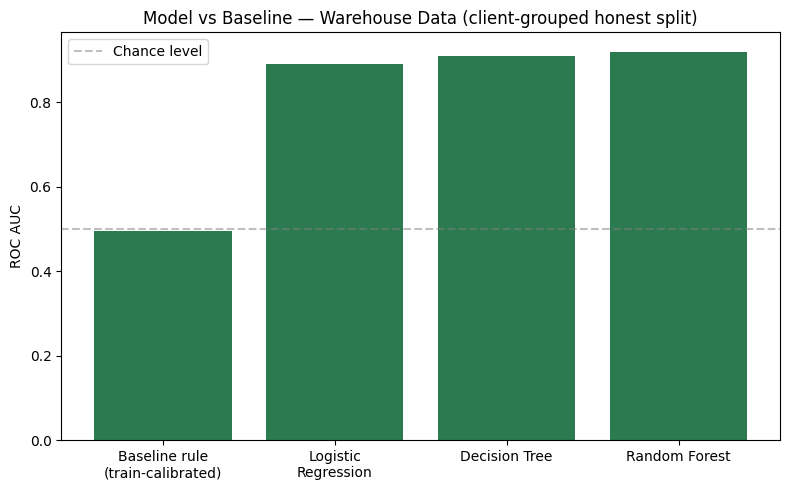

Saved: work/figures/model_vs_baseline_warehouse.png


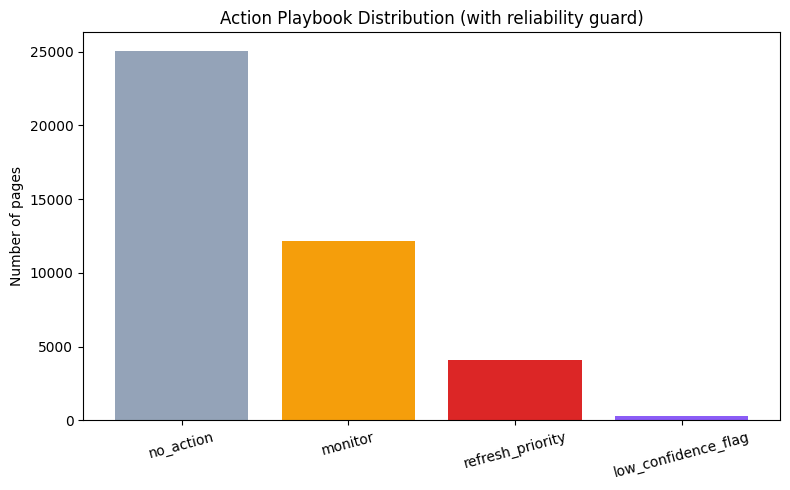

Saved: work/figures/action_distribution_warehouse.png


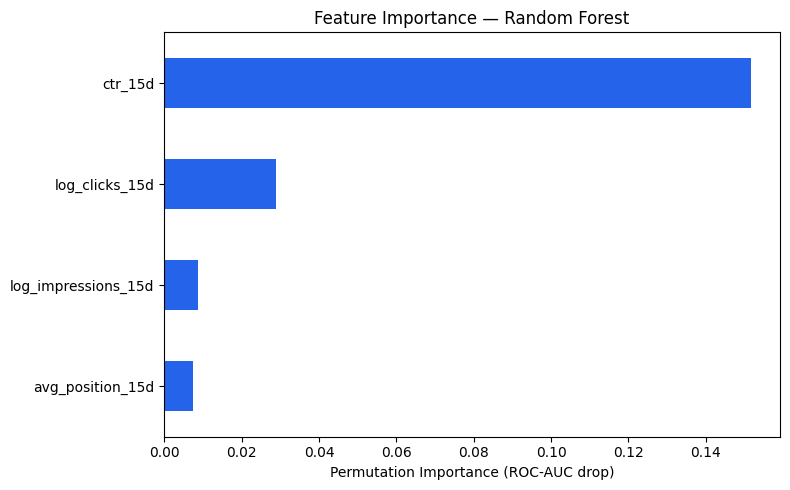

Saved: work/figures/feature_importance_warehouse.png

Metrics JSON saved.


In [13]:
import json, os
import matplotlib.pyplot as plt

os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

# Export the ranked queue
queue.to_csv('work/outputs/action_playbook_queue_warehouse.csv', index=False)
print(f"Queue exported: {len(queue)} rows")

# --- Chart 1: Model vs Baseline comparison (the key results chart) ---
fig, ax = plt.subplots(figsize=(8,5))
comparison_data = pd.DataFrame({
    'Method': ['Baseline rule\n(train-calibrated)', 'Logistic\nRegression', 'Decision Tree', 'Random Forest'],
    'ROC AUC': [0.496, 0.890, 0.911, 0.920]
})
ax.bar(comparison_data['Method'], comparison_data['ROC AUC'], color='#2c7a4f')
ax.set_ylabel('ROC AUC')
ax.set_title('Model vs Baseline — Warehouse Data (client-grouped honest split)')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Chance level')
ax.legend()
plt.tight_layout()
plt.savefig('work/figures/model_vs_baseline_warehouse.png', dpi=150)
plt.show()
print("Saved: work/figures/model_vs_baseline_warehouse.png")

# --- Chart 2: Action label distribution (shows the reliability guard's effect) ---
fig, ax = plt.subplots(figsize=(8,5))
action_counts = queue['action_label'].value_counts()
colors = {'no_action': '#94a3b8', 'monitor': '#f59e0b', 'refresh_priority': '#dc2626', 'low_confidence_flag': '#8b5cf6'}
ax.bar(action_counts.index, action_counts.values, color=[colors.get(x, '#666') for x in action_counts.index])
ax.set_ylabel('Number of pages')
ax.set_title('Action Playbook Distribution (with reliability guard)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('work/figures/action_distribution_warehouse.png', dpi=150)
plt.show()
print("Saved: work/figures/action_distribution_warehouse.png")

# --- Chart 3: Permutation importance ---
fig, ax = plt.subplots(figsize=(8,5))
importance_data = pd.Series({'ctr_15d': 0.1516, 'log_clicks_15d': 0.0289, 'log_impressions_15d': 0.0088, 'avg_position_15d': 0.0074})
importance_data.sort_values().plot(kind='barh', ax=ax, color='#2563eb')
ax.set_xlabel('Permutation Importance (ROC-AUC drop)')
ax.set_title('Feature Importance — Random Forest')
plt.tight_layout()
plt.savefig('work/figures/feature_importance_warehouse.png', dpi=150)
plt.show()
print("Saved: work/figures/feature_importance_warehouse.png")

# Metrics JSON
metrics = {
    'model': 'RandomForestClassifier',
    'data_source': 'FlyRank warehouse, month=2026-03',
    'split_method': 'client_grouped',
    'roc_auc': 0.921,
    'train_clients': 30,
    'test_clients': 14,
    'reliability_guard_threshold_impressions': 30,
    'action_label_counts': queue['action_label'].value_counts().to_dict(),
    'low_confidence_flag_count': int((test_df['action_label']=='low_confidence_flag').sum()),
    'top_permutation_features': {'ctr_15d': 0.1516, 'log_clicks_15d': 0.0289},
}
with open('work/outputs/w07_playbook_metrics_warehouse.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print("\nMetrics JSON saved.")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.